# Тема 4. Линейные модели

## Занятие 4 (теория)

**Дерево решений на занятии 3 дало 93-94% на данных оттока** — заметно лучше нашего ручного правила, но результат — дерево из вложенных «если-то», которое неудобно пересказать одной фразой. Линейные модели устроены по-другому: предсказание — это просто взвешенная сумма признаков. Каждый коэффициент — понятный вклад признака, который можно показать бизнесу без картинки дерева.

**План занятия:** линейная регрессия и МНК → недообучение/переобучение и регуляризация (Ridge/Lasso) → логистическая регрессия на данных оттока → где линейные модели проигрывают (XOR) → кривые валидации.

**Практика** — в `lesson04_linear_models_practice.ipynb` (Titanic — логистическая регрессия против дерева из темы 3).
**Дополнительно** (вывод функции потерь через MLE, анализ тональности отзывов, подробный перебор `C`) — в `lesson04_linear_models_advanced.ipynb`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, LogisticRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split, validation_curve
from sklearn.tree import DecisionTreeClassifier

%config InlineBackend.figure_format = 'svg'
RANDOM_STATE = 42

---
## 1. Линейная регрессия: находим прямую

Задача: предсказать число (не класс, как раньше) по одному или нескольким признакам. Линейная регрессия ищет прямую (или гиперплоскость), которая минимизирует сумму квадратов отклонений от неё — **метод наименьших квадратов (МНК)**.

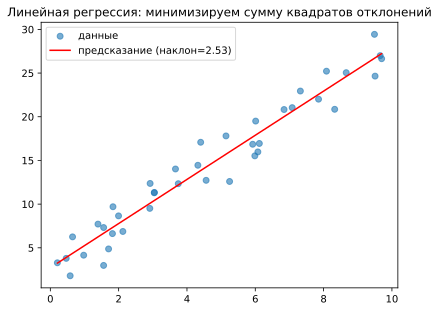

In [2]:
rng = np.random.RandomState(RANDOM_STATE)
X_demo = rng.uniform(0, 10, size=(40, 1))
y_demo = 2.5 * X_demo.ravel() + 3 + rng.normal(0, 2, 40)

lr_demo = LinearRegression().fit(X_demo, y_demo)

plt.scatter(X_demo, y_demo, alpha=0.6, label="данные")
plt.plot(X_demo, lr_demo.predict(X_demo), color="red", label=f"предсказание (наклон={lr_demo.coef_[0]:.2f})")
plt.legend()
plt.title("Линейная регрессия: минимизируем сумму квадратов отклонений");

Коэффициент (наклон) — это и есть смысл модели: «при увеличении признака на 1 единицу предсказание меняется на столько-то». Ничего похожего на дерево решений не даёт — там ответ на вопрос «на сколько» неочевиден.

---
## 2. Недо- и переобучение: тот же компромисс, что с глубиной дерева

На занятии 3 глубина дерева управляла сложностью модели: маленькая глубина — простая прямая граница (недообучение), большая — изрезанная граница по каждой точке (переобучение). У линейной модели роль «сложности» играет **степень полинома признаков** — если подать модели не только `x`, но и `x², x³, ...`.

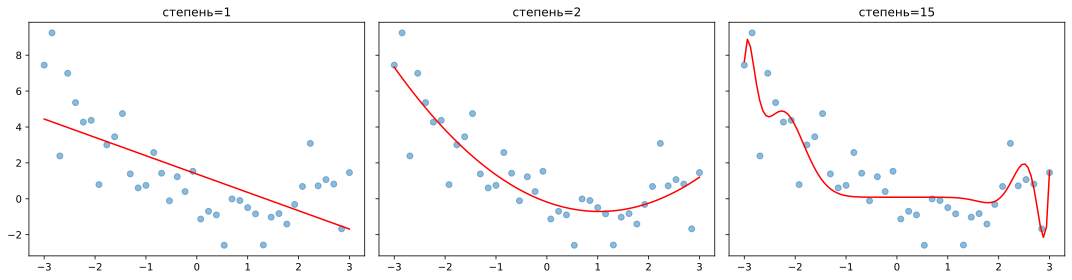

In [3]:
X_toy = np.linspace(-3, 3, 40).reshape(-1, 1)
y_toy = 0.5 * X_toy.ravel() ** 2 - X_toy.ravel() + rng.normal(0, 1.5, 40)
X_line = np.linspace(-3, 3, 100).reshape(-1, 1)

_, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, degree in zip(axes, [1, 2, 15]):
    model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
    model.fit(X_toy, y_toy)
    ax.scatter(X_toy, y_toy, alpha=0.5)
    ax.plot(X_line, model.predict(X_line), color="red")
    ax.set_title(f"степень={degree}")
plt.tight_layout();

Степень 1 — прямая, не улавливает изгиб данных (**недообучение**). Степень 2 — похоже на правду. Степень 15 — модель гоняется за каждой точкой, включая шум (**переобучение**), совсем как дерево неограниченной глубины на занятии 3.

**Регуляризация** решает эту проблему иначе, чем `max_depth` у дерева: не ограничивает сложность признаков напрямую, а **штрафует модель за большие коэффициенты** — добавляет к функции потерь слагаемое, растущее вместе с величиной коэффициентов.

- **Ridge (L2-регуляризация)** — штраф за сумму квадратов коэффициентов, коэффициенты становятся маленькими, но обычно не нулевыми.
- **Lasso (L1-регуляризация)** — штраф за сумму модулей коэффициентов, часть коэффициентов обнуляется целиком — это заодно и отбор признаков.

Возьмём переобученную модель (степень 15) и применим `Ridge` с разным `alpha` (сила регуляризации):

/var/lib/sadmin/Рабочий стол/ML-course/mlcourse.ai/.venv/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:227: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.7167113637934354e-18.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


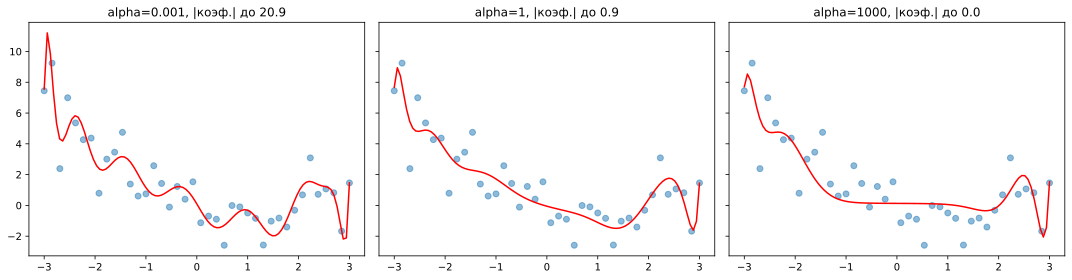

In [4]:
_, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, alpha in zip(axes, [0.001, 1, 1000]):
    model = make_pipeline(PolynomialFeatures(15), Ridge(alpha=alpha))
    model.fit(X_toy, y_toy)
    ax.scatter(X_toy, y_toy, alpha=0.5)
    ax.plot(X_line, model.predict(X_line), color="red")
    coefs = model.named_steps["ridge"].coef_
    ax.set_title(f"alpha={alpha}, |коэф.| до {np.abs(coefs).max():.1f}")
plt.tight_layout();

Чем больше `alpha`, тем сильнее штраф, тем более гладкая (и менее подогнанная под шум) кривая. Слишком большой `alpha` — недообучение в другую сторону, модель становится слишком простой.

---
## 3. Логистическая регрессия на данных оттока

Для классификации (0/1, как `Churn`) линейная модель предсказывает не сам класс, а **вероятность** класса 1 — линейную комбинацию признаков пропускают через сигмоиду $\sigma(z) = \frac{1}{1+e^{-z}}$, которая сжимает любое число в диапазон (0, 1).

Подготовка данных — та же, что в теме 3 (кодируем `International plan`/`Voice mail plan`, делим на train/valid), плюс новый обязательный шаг: **масштабирование** через `StandardScaler` — коэффициенты линейной модели чувствительны к масштабу признаков, в отличие от дерева.

In [5]:
df = pd.read_csv("../data/telecom_churn.csv")
df["Churn"] = df["Churn"].astype(int)
df["International plan"] = (df["International plan"] == "Yes").astype(int)
df["Voice mail plan"] = (df["Voice mail plan"] == "Yes").astype(int)

X = df.drop(columns=["State", "Churn"])
y = df["Churn"]
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_valid_s = scaler.transform(X_valid)

logreg = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)
logreg.fit(X_train_s, y_train)
round(logreg.score(X_valid_s, y_valid), 3)

0.865

**86.5%** — лучше ручного правила (85.8%), но заметно хуже дерева (93-94%). Посмотрим на коэффициенты — какие признаки модель считает важными и в какую сторону.

**Задание преподавателю на занятии:** `logreg.coef_[0]` — массив коэффициентов в том же порядке, что колонки `X`. Соберите в `pd.Series` с `index=X.columns`, отсортируйте и постройте `barh` — тот же приём, что с `feature_importances_` дерева в теме 3.

In [ ]:
# coefs = pd.Series(logreg.coef_[0], index=X.columns).sort_values()
# coefs.plot(kind="barh")


Положительные коэффициенты повышают вероятность оттока (`Customer service calls`, `International plan`) — согласуется с темами 1-3. Но обратите внимание на `Total day minutes` и `Total day charge` — на занятии 2 мы выяснили, что они коррелируют почти в 1 (`charge` считается из `minutes`). Дереву это не мешает, а **линейная модель делит вклад между двумя почти одинаковыми признаками**, и коэффициент каждого по отдельности занижен и ненадёжен. Уберём производные `charge`-признаки, как и планировали на занятии 2:

In [6]:
drop_cols = ["State", "Churn", "Total day charge", "Total eve charge", "Total night charge", "Total intl charge"]
X2 = df.drop(columns=drop_cols)
X2_train, X2_valid, y_train2, y_valid2 = train_test_split(
    X2, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y
)
X2_train_s = scaler.fit_transform(X2_train)
X2_valid_s = scaler.transform(X2_valid)

logreg2 = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000).fit(X2_train_s, y_train2)
print("accuracy:", round(logreg2.score(X2_valid_s, y_valid2), 3))
print("коэффициент Total day minutes:", round(pd.Series(logreg2.coef_[0], index=X2.columns)["Total day minutes"], 3))

accuracy: 0.865
коэффициент Total day minutes: 0.625


Точность не изменилась (та же информация никуда не делась), а коэффициент `Total day minutes` **вырос почти вдвое** — теперь он честно отражает весь эффект признака, а не половину. Мультиколлинеарность не портит точность предсказания, но портит интерпретируемость — а ради интерпретируемости мы линейную модель и выбираем.

**Три занятия — три результата на одной задаче:**

| Подход | Точность |
|---|---|
| Ручное правило (тема 1) | 85.8% |
| Логистическая регрессия (тема 4) | 86.5% |
| Дерево решений (тема 3) | 93-94% |

---
## 4. Где линейная модель бессильна: XOR

Линейная модель проводит **одну прямую (гиперплоскость)** между классами. Если границу нельзя провести прямой — модель не справится в принципе, сколько данных ни давай. Классический пример — XOR: класс 1, если ровно один из двух признаков положительный.

Логрегрессия на XOR (train accuracy): 0.54
Дерево на XOR (train accuracy):       1.0


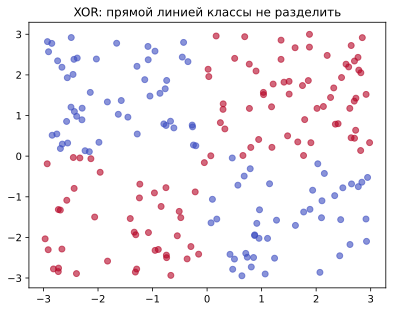

In [7]:
X_xor = rng.uniform(-3, 3, size=(200, 2))
y_xor = (X_xor[:, 0] * X_xor[:, 1] > 0).astype(int)

logreg_xor = LogisticRegression().fit(X_xor, y_xor)
tree_xor = DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE).fit(X_xor, y_xor)

print("Логрегрессия на XOR (train accuracy):", round(logreg_xor.score(X_xor, y_xor), 3))
print("Дерево на XOR (train accuracy):      ", round(tree_xor.score(X_xor, y_xor), 3))

plt.scatter(X_xor[:, 0], X_xor[:, 1], c=y_xor, cmap="coolwarm", alpha=0.6)
plt.title("XOR: прямой линией классы не разделить");

Логистическая регрессия — на уровне случайного угадывания (~50%), потому что честно ищет прямую линию, а её здесь нет ни одной удачной. Дерево — 100%, потому что режет пространство на прямоугольники, а не одной прямой. **Вывод не «линейные модели хуже»**, а «выбор модели зависит от формы зависимости в данных» — то же самое мы уже увидели на MNIST в `lesson03_trees_knn_advanced.ipynb`, только наоборот.

---
## 5. Кривая валидации: подбираем силу регуляризации

В `LogisticRegression` за силу регуляризации отвечает `C` — **обратный** коэффициент (меньше `C` → сильнее регуляризация, как ни странно устроено в sklearn). Переберём несколько значений и посмотрим на accuracy при кросс-валидации — тот же принцип, что и график train/valid по глубине дерева на практике темы 3:

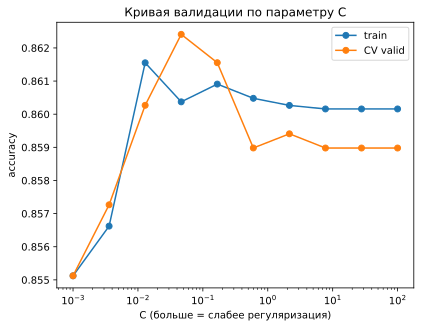

In [8]:
Cs = np.logspace(-3, 2, 10)
train_scores, valid_scores = validation_curve(
    LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    X_train_s, y_train, param_name="C", param_range=Cs, cv=5,
)

plt.plot(Cs, train_scores.mean(axis=1), marker="o", label="train")
plt.plot(Cs, valid_scores.mean(axis=1), marker="o", label="CV valid")
plt.xscale("log")
plt.xlabel("C (больше = слабее регуляризация)")
plt.ylabel("accuracy")
plt.legend()
plt.title("Кривая валидации по параметру C");

На этом датасете кривая почти плоская — регуляризация здесь мало что меняет, у нас достаточно данных относительно числа признаков, переобучиться линейной модели сложно. График скорее иллюстрирует **метод**: так же можно подбирать любой гиперпараметр любой модели (в том числе `max_depth` дерева из темы 3), не только `C`.

---
## Итог занятия

Сегодня разобрали:

- Линейная регрессия и МНК — коэффициент как интерпретируемый вклад признака
- Недо-/переобучение через степень полинома, регуляризация (Ridge/Lasso) как альтернатива `max_depth`
- Логистическая регрессия на оттоке — 86.5%, интерпретируемые коэффициенты, важность удаления коррелированных признаков
- XOR — где линейная граница принципиально не работает
- Кривая валидации — общий метод подбора гиперпараметра любой модели

**Дальше:**
- Практика — `lesson04_linear_models_practice.ipynb` (Titanic: логрегрессия против дерева)
- Доп. материалы — `lesson04_linear_models_advanced.ipynb`
- Следующее занятие — ансамблевые методы и случайный лес